<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Logo-gustave-roussy.jpg/1200px-Logo-gustave-roussy.jpg" alt="Logo 1" width="250"/>
  <img src="https://upload.wikimedia.org/wikipedia/en/thumb/3/3f/Qube_Research_%26_Technologies_Logo.svg/1200px-Qube_Research_%26_Technologies_Logo.svg.png" alt="Logo 2" width="200" style="margin-left: 20px;"/>
</p>

# Data Challenge : Leukemia Risk Prediction


*GOAL OF THE CHALLENGE and WHY IT IS IMPORTANT:*

The goal of the challenge is to **predict disease risk for patients with blood cancer**, in the context of specific subtypes of adult myeloid leukemias.

The risk is measured through the **overall survival** of patients, i.e. the duration of survival from the diagnosis of the blood cancer to the time of death or last follow-up.

Estimating the prognosis of patients is critical for an optimal clinical management. 
For exemple, patients with low risk-disease will be offered supportive care to improve blood counts and quality of life, while patients with high-risk disease will be considered for hematopoietic stem cell transplantion.

The performance metric used in the challenge is the **IPCW-C-Index**.

*THE DATASETS*

The **training set is made of 3,323 patients**.

The **test set is made of 1,193 patients**.

For each patient, you have acces to CLINICAL data and MOLECULAR data.

The details of the data are as follows:

- OUTCOME:
  * OS_YEARS = Overall survival time in years
  * OS_STATUS = 1 (death) , 0 (alive at the last follow-up)

- CLINICAL DATA, with one line per patient:
  
  * ID = unique identifier per patient
  * CENTER = clinical center
  * BM_BLAST = Bone marrow blasts in % (blasts are abnormal blood cells)
  * WBC = White Blood Cell count in Giga/L 
  * ANC = Absolute Neutrophil count in Giga/L
  * MONOCYTES = Monocyte count in Giga/L
  * HB = Hemoglobin in g/dL
  * PLT = Platelets coutn in Giga/L
  * CYTOGENETICS = A description of the karyotype observed in the blood cells of the patients, measured by a cytogeneticist. Cytogenetics is the science of chromosomes. A karyotype is performed from the blood tumoral cells. The convention for notation is ISCN (https://en.wikipedia.org/wiki/International_System_for_Human_Cytogenomic_Nomenclature). Cytogenetic notation are: https://en.wikipedia.org/wiki/Cytogenetic_notation. Note that a karyotype can be normal or abnornal. The notation 46,XX denotes a normal karyotype in females (23 pairs of chromosomes including 2 chromosomes X) and 46,XY in males (23 pairs of chromosomes inclusing 1 chromosme X and 1 chromsome Y). A common abnormality in the blood cancerous cells might be for exemple a loss of chromosome 7 (monosomy 7, or -7), which is typically asssociated with higher risk disease

- GENE MOLECULAR DATA, with one line per patient per somatic mutation. Mutations are detected from the sequencing of the blood tumoral cells. 
We call somatic (= acquired) mutations the mutations that are found in the tumoral cells but not in other cells of the body.

  * ID = unique identifier per patient
  * CHR START END = position of the mutation on the human genome
  * REF ALT = reference and alternate (=mutant) nucleotide
  * GENE = the affected gene
  * PROTEIN_CHANGE = the consequence of the mutation on the protei that is expressed by a given gene
  * EFFECT = a broad categorization of the mutation consequences on a given gene.
  * VAF = Variant Allele Fraction = it represents the **proportion** of cells with the deleterious mutations. 

In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

# Clinical Data
df = pd.read_csv("./data/X_train/clinical_train.csv")
df_eval = pd.read_csv("./data/X_test/clinical_test.csv")

# Molecular Data
maf_df = pd.read_csv("./data/X_train/molecular_train.csv")
maf_eval = pd.read_csv("./data/X_test/molecular_test.csv")

target_df = pd.read_csv("./data/target_train.csv")

# TODO : Uncomment for test data ??
"""
target_df_test = pd.read_csv("./data/target_test.csv")
"""
# Preview the data
df.head()

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"


In [5]:
# Visualise Y_train
target_df.head()

,ID,OS_YEARS,OS_STATUS
0,P132697,1.115068,1.0
1,P132698,4.928767,0.0
2,P116889,2.043836,0.0
3,P132699,2.476712,1.0
4,P132700,3.145205,0.0


In [6]:
# Visualise Gene Molecular Data
maf_df.head()

,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
0,P100000,11,119149248.0,119149248.0,G,A,CBL,p.C419Y,non_synonymous_codon,0.0830,1308.0
1,P100000,5,131822301.0,131822301.0,G,T,IRF1,p.Y164*,stop_gained,0.0220,532.0
2,P100000,3,77694060.0,77694060.0,G,C,ROBO2,p.?,splice_site_variant,0.4100,876.0
3,P100000,4,106164917.0,106164917.0,G,T,TET2,p.R1262L,non_synonymous_codon,0.4300,826.0
4,P100000,2,25468147.0,25468163.0,ACGAAGAGGGGGTGTTC,A,DNMT3A,p.E505fs*141,frameshift_variant,0.0898,942.0


### Step 1: Data Preparation (clinical data only)

For survival analysis, we’ll format the dataset so that OS_YEARS represents the time variable and OS_STATUS represents the event indicator.

In [7]:
# Drop rows where 'OS_YEARS' is NaN if conversion caused any issues
target_df.dropna(subset=['OS_YEARS', 'OS_STATUS'], inplace=True)

# Check the data types to ensure 'OS_STATUS' is boolean and 'OS_YEARS' is numeric
print(target_df[['OS_STATUS', 'OS_YEARS']].dtypes)

# Contarget_dfvert 'OS_YEARS' to numeric if it isn’t already
target_df['OS_YEARS'] = pd.to_numeric(target_df['OS_YEARS'], errors='coerce')

# Ensure 'OS_STATUS' is boolean
target_df['OS_STATUS'] = target_df['OS_STATUS'].astype(bool)

# Select features
features = ['BM_BLAST', 'HB', 'PLT']
target = ['OS_YEARS', 'OS_STATUS']

# Create the survival data format
X = df.loc[df['ID'].isin(target_df['ID']), features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

OS_STATUS    float64
OS_YEARS     float64
dtype: object


In [8]:
# Count the number of unique values for each column
unique_values_count = maf_df.nunique()
print(unique_values_count)

ID                3026
CHR                 23
START             4645
END               4664
REF                406
ALT                332
GENE               124
PROTEIN_CHANGE    4686
EFFECT              16
VAF               2952
DEPTH             2268
dtype: int64


### Step 2: Splitting the Dataset
We’ll split the data into training and testing sets to evaluate the model’s performance.

In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
# Survival-aware imputation for missing values
imputer = SimpleImputer(strategy="median")
X_train[['BM_BLAST', 'HB', 'PLT']] = imputer.fit_transform(X_train[['BM_BLAST', 'HB', 'PLT']])
X_test[['BM_BLAST', 'HB', 'PLT']] = imputer.transform(X_test[['BM_BLAST', 'HB', 'PLT']])

### Step 3: Training Standard Machine Learning Methods

In this step, we train a standard LightGBM model on survival data, but we do not account for censoring. Instead of treating the event status, we use only the observed survival times as the target variable. This approach disregards whether an individual’s event (e.g., death) was observed or censored, effectively treating the problem as a standard regression task. While this method provides a basic benchmark, it may be less accurate than survival-specific models (but still be explored!), as it does not leverage the information contained in censored observations.

In [11]:
# Import necessary libraries
import lightgbm as lgb
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# Define LightGBM parameters
lgbm_params = {
    'max_depth': 3,
    'learning_rate': 0.05,
    'verbose': -1
}

# Prepare the data for LightGBM
# Scale the target (OS_YEARS) to reduce skew, apply weights based on event status
X_train_lgb = X_train  # Features for training
y_train_transformed = y_train['OS_YEARS']

# Create LightGBM dataset
train_dataset = lgb.Dataset(X_train_lgb, label=y_train_transformed)

# Train the LightGBM model
model = lgb.train(params=lgbm_params, train_set=train_dataset)

# Make predictions on the training and testing sets
pred_train = -model.predict(X_train)
pred_test = -model.predict(X_test)

# Evaluate the model using Concordance Index IPCW
train_ci_ipcw = concordance_index_ipcw(y_train, y_train, pred_train, tau=7)[0]
test_ci_ipcw = concordance_index_ipcw(y_train, y_test, pred_test, tau=7)[0]
print(f"LightGBM Survival Model Concordance Index IPCW on train: {train_ci_ipcw:.2f}")
print(f"LightGBM Survival Model Concordance Index IPCW on test: {test_ci_ipcw:.2f}")


LightGBM Survival Model Concordance Index IPCW on train: 0.69
LightGBM Survival Model Concordance Index IPCW on test: 0.65


<Figure size 2000x1000 with 0 Axes>

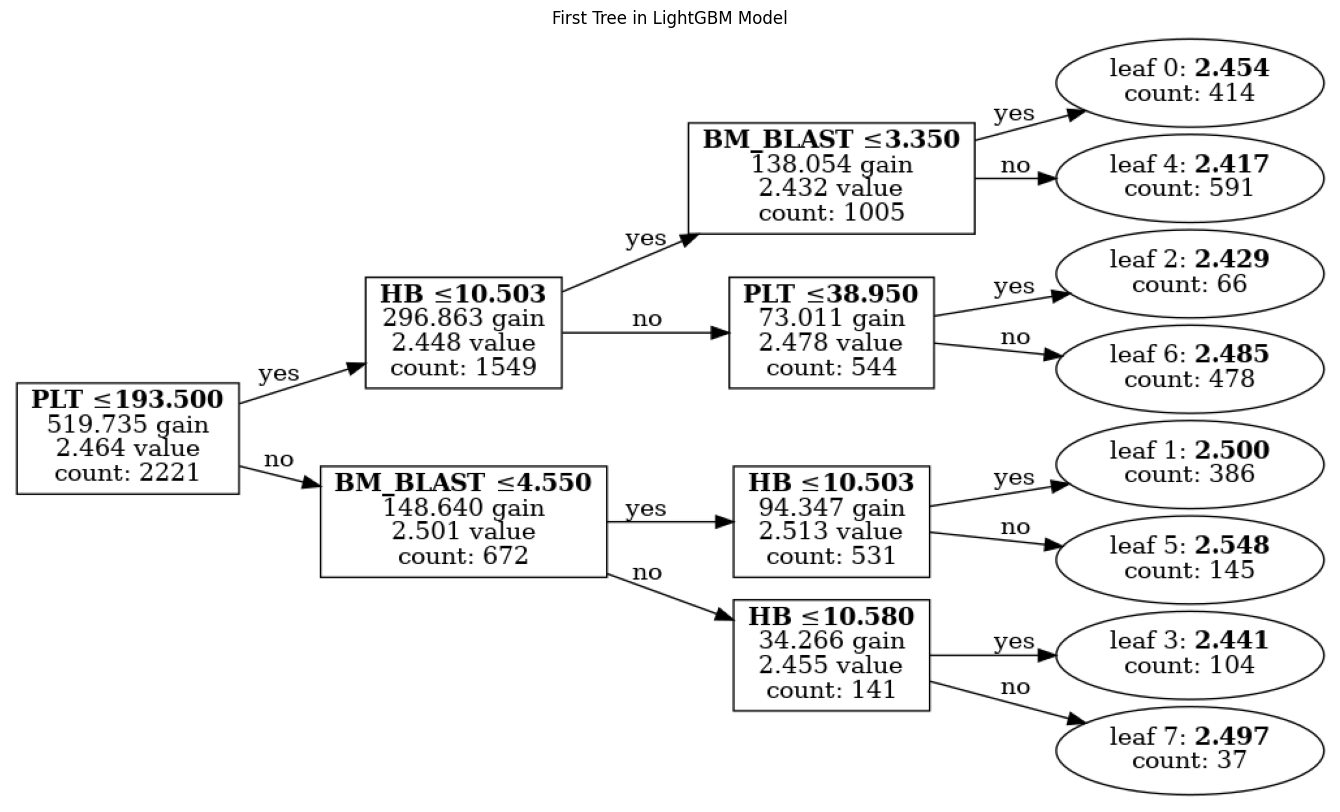

In [12]:
# Assuming the LightGBM model is defined as `model`
plt.figure(figsize=(20, 10))
lgb.plot_tree(model, tree_index=0, figsize=(20, 10), show_info=['split_gain', 'internal_value', 'internal_count', 'leaf_count'])
plt.title("First Tree in LightGBM Model")
plt.show()

### Step 4: Cox Proportional Hazards Model

To account for censoring in survival analysis, we use a Cox Proportional Hazards (Cox PH) model, a widely used method that estimates the effect of covariates on survival times without assuming a specific baseline survival distribution. The Cox PH model is based on the hazard function, $h(t | X)$, which represents the instantaneous risk of an event (e.g., death) at time $t$ given covariates $X$. The model assumes that the hazard can be expressed as:

$$h(t | X) = h_0(t) \exp(\beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p)$$


where $h_0(t)$ is the baseline hazard function, and $\beta$ values are coefficients for each covariate, representing the effect of $X$ on the hazard. Importantly, the proportional hazards assumption implies that the hazard ratios between individuals are constant over time. This approach effectively leverages both observed and censored survival times, making it a more suitable method for survival data compared to standard regression techniques that ignore censoring.


In [13]:
# Initialize and train the Cox Proportional Hazards model
cox = CoxPHSurvivalAnalysis()
cox.fit(X_train, y_train)

# Evaluate the model using Concordance Index IPCW
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {cox_cindex_train:.2f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {cox_cindex_test:.2f}")

Cox Proportional Hazard Model Concordance Index IPCW on train: 0.66
Cox Proportional Hazard Model Concordance Index IPCW on test: 0.66


### Step 5: Naive Approach to Incorporate Mutations

In this step, we take a very naive approach to account for genetic mutations by simply counting the total number of somatic mutations per patient. Instead of analyzing specific mutations or their biological impact, we use this aggregate count as a basic feature to reflect the mutational burden for each individual. Although simplistic, this feature can serve as a general indicator of genetic variability across patients, which may influence survival outcomes. More sophisticated mutation analysis could be incorporated in future models to improve predictive power.


In [14]:
# Step: Extract the number of somatic mutations per patient
# Group by 'ID' and count the number of mutations (rows) per patient
tmp = maf_df.groupby('ID').size().reset_index(name='Nmut')

# Merge with the training dataset and replace missing values in 'Nmut' with 0
df_2 = df.merge(tmp, on='ID', how='left').fillna({'Nmut': 0})

In [15]:
# Select features
features = ['BM_BLAST', 'HB', 'PLT', 'Nmut']
target = ['OS_YEARS', 'OS_STATUS']

# Create the survival data format
X = df_2.loc[df_2['ID'].isin(target_df['ID']), features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

df_2

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,Nmut
0,P132697,MSK,14.0,2.80,0.20,0.70,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",9.0
1,P132698,MSK,1.0,7.40,2.40,0.10,11.6,42.0,"46,xx",3.0
2,P116889,MSK,15.0,3.70,2.10,0.10,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",3.0
3,P132699,MSK,1.0,3.90,1.90,0.10,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",11.0
4,P132700,MSK,6.0,128.00,9.70,0.90,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",1.0
...,...,...,...,...,...,...,...,...,...,...
3318,P121828,VU,1.0,3.70,2.53,0.53,8.9,499.0,"46,xy[20]",2.0
3319,P121829,VU,0.0,4.20,2.40,0.22,10.6,49.0,"46,xy,del(13)(q12q14)[1]/45,x,-y,del(13)(q12q1...",1.0
3320,P121830,VU,0.0,1.80,0.55,0.29,9.4,86.0,"46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]",6.0
3321,P121853,VU,5.0,1.37,0.37,0.11,11.4,102.0,"46,xx,del(1)(p34)[5]/45,xx,sl,-18[12]/46,xx,sd...",4.0


In [17]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [18]:
# Survival-aware imputation for missing values
imputer = SimpleImputer(strategy="median")
X_train[['BM_BLAST', 'HB', 'PLT', 'Nmut']] = imputer.fit_transform(X_train[['BM_BLAST', 'HB', 'PLT', 'Nmut']])
X_test[['BM_BLAST', 'HB', 'PLT', 'Nmut']] = imputer.transform(X_test[['BM_BLAST', 'HB', 'PLT', 'Nmut']])

In [19]:
# Initialize and train the Cox Proportional Hazards model
cox = CoxPHSurvivalAnalysis()
cox.fit(X_train, y_train)

# Evaluate the model using Concordance Index IPCW
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {cox_cindex_train:.2f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {cox_cindex_test:.2f}")

Cox Proportional Hazard Model Concordance Index IPCW on train: 0.68
Cox Proportional Hazard Model Concordance Index IPCW on test: 0.68


### Inference on test set

In [20]:

tmp_eval = maf_eval.groupby('ID').size().reset_index(name='Nmut')

# Merge with the training dataset and replace missing values in 'Nmut' with 0
df_eval = df_eval.merge(tmp_eval, on='ID', how='left').fillna({'Nmut': 0})



In [21]:
df_eval[['BM_BLAST', 'HB', 'PLT', 'Nmut']] = imputer.transform(df_eval[['BM_BLAST', 'HB', 'PLT', 'Nmut']])

prediction_on_test_set = cox.predict(df_eval.loc[:, features])

In [22]:
prediction_on_test_set

array([ 0.86383932, -0.5138395 , -1.73261271, ..., -1.69091907,
       -1.44228073, -1.5665999 ])

In [ ]:
submission = pd.Series(prediction_on_test_set, index=df_eval['ID'], name='risk_score')

In [24]:
submission

ID
KYW1       0.863839
KYW2      -0.513840
KYW3      -1.732613
KYW4       0.493821
KYW5      -1.125188
             ...   
KYW1189   -1.566600
KYW1190   -1.442281
KYW1191   -1.690919
KYW1192   -1.442281
KYW1193   -1.566600
Name: risk_score, Length: 1193, dtype: float64

In [55]:

submission.to_csv('./submission/benchmark_submission.csv')

In [56]:
submission.head()

ID
KYW1    1.389423
KYW2   -0.077273
KYW3   -1.266949
KYW4    0.518468
KYW5    0.228392
Name: OS_YEARS, dtype: float64

In [57]:

random_submission = pd.Series(np.random.uniform(0, 1, len(submission)),index =submission.index, name='OS_YEARS')


In [58]:
random_submission.to_csv('./submission/random_submission.csv')

In [59]:
random_submission.head()

ID
KYW1    0.939945
KYW2    0.916365
KYW3    0.826057
KYW4    0.239456
KYW5    0.176320
Name: OS_YEARS, dtype: float64

### Step 6: Using molecular data

#### Utilitary functions on Clinical data

In [108]:
import re
# Functions to detect features in Clinical Data


def quantify_cytogenetic_abnormalities(df, col='CYTOGENETICS'):
    """
    Sum numeric counts inside [...] for abnormal clones in df[col].
    - Splits clones on '/' but NOT on slashes inside square brackets.
    - Skips clones that are truly normal karyotypes like '46,XY[20]' or '46,XX[20]'.
    - Ignores non-numeric bracket contents (e.g. 'cp9').
    """
    if col not in df.columns:
        raise ValueError(f"The dataframe must contain a '{col}' column.")
    
    # split on '/' that are NOT inside square brackets
    split_outside_brackets_re = re.compile(r'/(?![^\[]*\])')

    # regex to detect pure normal clone starting with 46,xy[ or 46,xx[
    pure_normal_clone_re = re.compile(r'^\s*46\s*,\s*(xx|xy)\s*\[', flags=re.IGNORECASE)

    bracket_re = re.compile(r'\[([^\]]+)\]')

    def count_abnormal_metaphases(karyo):
        if not isinstance(karyo, str) or not karyo.strip():
            return 0

        total = 0
        # split clones but don't split slashes inside brackets like [19/20]
        clones = [c.strip() for c in split_outside_brackets_re.split(karyo) if c and c.strip()]

        for clone in clones:
            # if clone is a pure normal clone like "46,xy[18]" -> skip
            if pure_normal_clone_re.search(clone):
                continue

            # find first bracketed content in this clone
            m = bracket_re.search(clone)
            if not m:
                continue

            # take the left side of any internal slash inside the bracket (e.g. '19/20' -> '19')
            val = m.group(1).split('/')[0].strip()

            # count only if purely numeric
            if val.isdigit():
                total += int(val)
            # else ignore cp9, ish, etc.

        return total

    # apply safely even if there are NaNs
    return df[col].fillna('').astype(str).apply(count_abnormal_metaphases)

def detect_monosomy_7(df):
    """
    Detects the presence of monosomy 7 (-7) in the CYTOGENETICS column of the clinical data.
    """
    if 'CYTOGENETICS' not in df.columns:
        raise ValueError("The dataframe must contain a 'CYTOGENETICS' column.")
    
    return df['CYTOGENETICS'].str.contains(r'(\-7|del\(7\))', na=False, regex=True)

def detect_monosomy_5(df):
    """
    Detects the presence of monosomy 5 (-5) in the CYTOGENETICS column of the clinical data.
    """
    if 'CYTOGENETICS' not in df.columns:
        raise ValueError("The dataframe must contain a 'CYTOGENETICS' column.")
    
    return df['CYTOGENETICS'].str.contains(r'(\-5|del\(5\))', na=False, regex=True)

def detect_monosomy_17(df):
    """
    Detects the presence of monosomy 5 (-5) in the CYTOGENETICS column of the clinical data.
    """
    if 'CYTOGENETICS' not in df.columns:
        raise ValueError("The dataframe must contain a 'CYTOGENETICS' column.")
    
    return df['CYTOGENETICS'].str.contains(r'(\-17|del\(17\))', na=False, regex=True)

def detect_oncogene(df):
    """
    Detects the presence of the Philadelphia chromosome (t(9;22)) in the CYTOGENETICS column of the clinical data.
    """
    if 'CYTOGENETICS' not in df.columns:
        raise ValueError("The dataframe must contain a 'CYTOGENETICS' column.")
    
    return df['CYTOGENETICS'].str.contains(r'(inv\(3\)\(q21q26\)|t\(3;3\)\(q21;q26\))', na=False, regex=True)

def detect_complex(df):
    """
    Detects the presence of complex karyotype in the CYTOGENETICS column of the clinical data.
    A complex karyotype is typically defined as having three or more chromosomal abnormalities.
    """
    if 'CYTOGENETICS' not in df.columns:
        raise ValueError("The dataframe must contain a 'CYTOGENETICS' column.")
    
    return df['CYTOGENETICS'].str.contains(r'complex', na=False, regex=True)

def count_anomalies(df):
    """
    Counts the number of chromosomal abnormalities in the CYTOGENETICS column of the clinical data.
    Assumes that abnormalities are separated by commas.
    """
    if 'CYTOGENETICS' not in df.columns:
        raise ValueError("The dataframe must contain a 'CYTOGENETICS' column.")
    
    return df['CYTOGENETICS'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

def count_anomalies_refined(df):
    """
    Counts the number of chromosomal abnormalities in the CYTOGENETICS column of the clinical data.
    Refined to exclude non-abnormality terms.
    """
    if 'CYTOGENETICS' not in df.columns:
        raise ValueError("The dataframe must contain a 'CYTOGENETICS' column.")
    
    tmp = df.copy()
    tmp['Monosomy_7'] = detect_monosomy_7(tmp)
    tmp['Monosomy_5'] = detect_monosomy_5(tmp)
    tmp['Monosomy_17'] = detect_monosomy_17(tmp)
    tmp['Oncogene'] = detect_oncogene(tmp)
    tmp['Complex'] = detect_complex(tmp)
    tmp['Anomaly_Count_Refined'] = tmp[['Monosomy_7', 'Monosomy_5', 'Monosomy_17', 'Oncogene', 'Complex']].sum(axis=1)
    return tmp['Anomaly_Count_Refined']

#### Utilitary functions on molecular data

In [361]:
# Functions to detect abnormalities in molecular Data
def count_mutations(df,maf_df):
    """
    Counts the number of somatic mutations per patient in the MAF dataframe.
    Assumes that each row represents a mutation and 'ID' column identifies patients.
    """
    tmp_df = df.copy()
    tmp_df['Mutation_Count'] = maf_df.groupby('ID').size().reindex(tmp_df['ID']).fillna(0).values
    return tmp_df['Mutation_Count']

def sum_VAF(df,maf_df):
    """
    Sums the Variant Allele Frequencies (VAF) of somatic mutations per patient in the MAF dataframe.
    Assumes that 'ID' column identifies patients and 'VAF' column contains the variant allele frequencies.
    """
    tmp_df = df.copy()
    vaf_sum = maf_df.groupby('ID')['VAF'].sum().reindex(tmp_df['ID']).fillna(0).values
    return vaf_sum

def count_CHRs(df,maf_df):
    """
    Ads columns named 1-22, X, Y to df indicating the sum of VAF mutations for each patient.
    """
    tmp_df = df.copy()
    chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y']
    
    for chrom in chromosomes:
        vaf_sum = maf_df[maf_df['CHR'] == chrom].groupby('ID').size().reindex(tmp_df['ID']).fillna(0).values
        tmp_df[chrom] = vaf_sum
    
    return tmp_df[chromosomes]

def count_Vaf_CHRs(df,maf_df):
    """
    Ads columns named 1-22, X, Y to df indicating the sum of VAF mutations for each patient.
    """
    tmp_df = df.copy()
    chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y']
    
    for chrom in chromosomes:
        vaf_sum = maf_df[maf_df['CHR'] == chrom].groupby('ID')['VAF'].sum().reindex(tmp_df['ID']).fillna(0).values
        tmp_df[chrom] = vaf_sum
    
    return tmp_df[chromosomes]

def lenght_reference(df,maf_df):
    """
    Sums the lengths of all mutations per patient in the MAF dataframe.
    Assumes that 'ID' column identifies patients and 'End_Position' and 'Start_Position' columns contain mutation positions.
    """
    return maf_df.groupby('ID')['REF'].apply(lambda x: x.str.len().max()).reindex(df['ID']).fillna(0).values

def start_end_depth_biggest_VAF(df, maf_df):
    # Filter rows with the maximum VAF value for each ID
    max_vaf_rows = maf_df.loc[maf_df.groupby('ID')['VAF'].idxmax().dropna().astype(int)]

    # Create the resulting dataframe with START, END, and DEPTH columns
    result_df = pd.DataFrame({
        'START': df['ID'].map(max_vaf_rows.set_index('ID')['START']).fillna(0).astype(int),
        'END': df['ID'].map(max_vaf_rows.set_index('ID')['END']).fillna(0).astype(int),
        'DEPTH': df['ID'].map(max_vaf_rows.set_index('ID')['DEPTH']).fillna(0).astype(int)
    })

    return result_df

def count_effects(df, maf_df):
    list_of_effects = maf_df['EFFECT'].unique().tolist()
    tmp_df = df.copy()
    for effect in list_of_effects:
        effect_count = maf_df[maf_df['EFFECT'] == effect].groupby('ID').size().reindex(tmp_df['ID']).fillna(0).values
        tmp_df[effect] = effect_count
    return tmp_df[list_of_effects],list_of_effects

def vaf_effects(df,maf_df):
    list_of_effects = maf_df['EFFECT'].unique().tolist()
    tmp_df = df.copy()
    for effect in list_of_effects:
        effect_vaf_sum = maf_df[maf_df['EFFECT'] == effect].groupby('ID')['VAF'].sum().reindex(tmp_df['ID']).fillna(0).values
        tmp_df[effect] = effect_vaf_sum
    return tmp_df[list_of_effects],list_of_effects

def count_REF(df,maf_df):
    list_of_refs = maf_df['REF'].unique().tolist()
    tmp_df = df.copy()
    for ref in list_of_refs:
        ref_count = maf_df[maf_df['REF'] == ref].groupby('ID').size().reindex(tmp_df['ID']).fillna(0).values
        tmp_df[ref] = ref_count
    return tmp_df[list_of_refs],list_of_refs

def count_GENE(df,maf_df):
    list_of_genes = maf_df['GENE'].unique().tolist()
    tmp_df = df.copy()
    for gene in list_of_genes:
        gene_count = maf_df[maf_df['GENE'] == gene].groupby('ID').size().reindex(tmp_df['ID']).fillna(0).values
        tmp_df[gene] = gene_count
    return tmp_df[list_of_genes],list_of_genes

#### Testing

In [362]:
# Apply the functions to create a new features
df_factors = df.copy()
'''
df_factors['Monosomy_7'] = detect_monosomy_7(df).astype(int)
df_factors['Monosomy_5'] = detect_monosomy_5(df).astype(int)
df_factors['Monosomy_17'] = detect_monosomy_17(df).astype(int)
df_factors['Oncogene'] = detect_oncogene(df).astype(int)
df_factors['Complex_Karyotype'] = detect_complex(df).astype(int)
df_factors['Anomaly_Count_Refined'] = count_anomalies_refined(df_factors)
'''
df_factors['Complex_Ref_Mutation'] = lenght_reference(df_factors, maf_df)

df_factors = pd.concat([df_factors, start_end_depth_biggest_VAF(df_factors, maf_df)], axis=1)

df_factors['Mutation_Count'] = count_mutations(df_factors, maf_df)

df_factors['Cytogenetic_Abnormality_Count'] = quantify_cytogenetic_abnormalities(df_factors)

df_factors = pd.concat([df_factors, count_Vaf_CHRs(df_factors, maf_df)], axis=1)

to_concat , list_effects = count_effects(df_factors, maf_df)
df_factors = pd.concat([df_factors, to_concat], axis=1)

to_concat , list_ref = count_REF(df_factors, maf_df)
df_factors = pd.concat([df_factors, to_concat], axis=1)

to_concat , list_genes = count_GENE(df_factors, maf_df)
df_factors = pd.concat([df_factors, to_concat], axis=1)

df_factors.head(10)

/tmp/ipykernel_24877/2619911274.py:87: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tmp_df[ref] = ref_count
/tmp/ipykernel_24877/2619911274.py:87: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tmp_df[ref] = ref_count
/tmp/ipykernel_24877/2619911274.py:87: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,Complex_Ref_Mutation,...,PTPRF,JAK3,BAP1,WHSC1,HIPK2,NXF1,CDKN2C,BCL10,ABL1,JARID2
0,P132697,MSK,14.0,2.8,0.2,0.70,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,P132698,MSK,1.0,7.4,2.4,0.10,11.6,42.0,"46,xx",1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,P116889,MSK,15.0,3.7,2.1,0.10,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,P132699,MSK,1.0,3.9,1.9,0.10,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,P132700,MSK,6.0,128.0,9.7,0.90,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,P132701,MSK,3.0,15.8,12.6,0.88,8.0,492.0,"46,xx[20]",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,P132702,MSK,12.0,6.2,3.0,0.80,9.6,61.0,"46,xy[20]",1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,P132703,MSK,15.0,4.8,1.5,0.70,9.4,142.0,"46,xy[20]",2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,P132704,MSK,14.0,0.8,0.2,0.00,8.8,23.0,"45,xx,del(5)(q13q33),inc[2]/46,xx[2]",1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,P132705,MSK,14.0,1.4,0.2,0.00,7.4,183.0,"46,xx[20]",2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [369]:
# Select features
Chromosomes = [str(i) for i in range(1, 23)] + ['X']
features = ['BM_BLAST', 'HB', 'PLT','Cytogenetic_Abnormality_Count','Mutation_Count', '4','17','NIPBL','NPM1']
target = ['OS_YEARS', 'OS_STATUS']

# Create the survival data format
X = df_factors.loc[df['ID'].isin(target_df['ID']), features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Survival-aware imputation for missing values
imputer = SimpleImputer(strategy="median")
X_train[features] = imputer.fit_transform(X_train[features])
X_test[features] = imputer.transform(X_test[features])

# Initialize and train the Cox Proportional Hazards model
cox = CoxPHSurvivalAnalysis()
cox.fit(X_train, y_train)
# Evaluate the model using Concordance Index IPCW
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {cox_cindex_train:.3f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {cox_cindex_test:.3f}")

Cox Proportional Hazard Model Concordance Index IPCW on train: 0.703
Cox Proportional Hazard Model Concordance Index IPCW on test: 0.695


##### Single feature test

/home/carl/.local/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:492: LinAlgWarning: Ill-conditioned matrix (rcond=9.4299e-156): result may not be accurate.
  delta = solve(
/home/carl/.local/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:197: RuntimeWarning: overflow encountered in exp
  risk_set2 += np.exp(xw[k])
/home/carl/.local/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:492: LinAlgWarning: Ill-conditioned matrix (rcond=1.07385e-79): result may not be accurate.
  delta = solve(
/home/carl/.local/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:492: LinAlgWarning: Ill-conditioned matrix (rcond=1.13224e-41): result may not be accurate.
  delta = solve(
/home/carl/.local/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:492: LinAlgWarning: Ill-conditioned matrix (rcond=1.15896e-22): result may not be accurate.
  delta = solve(


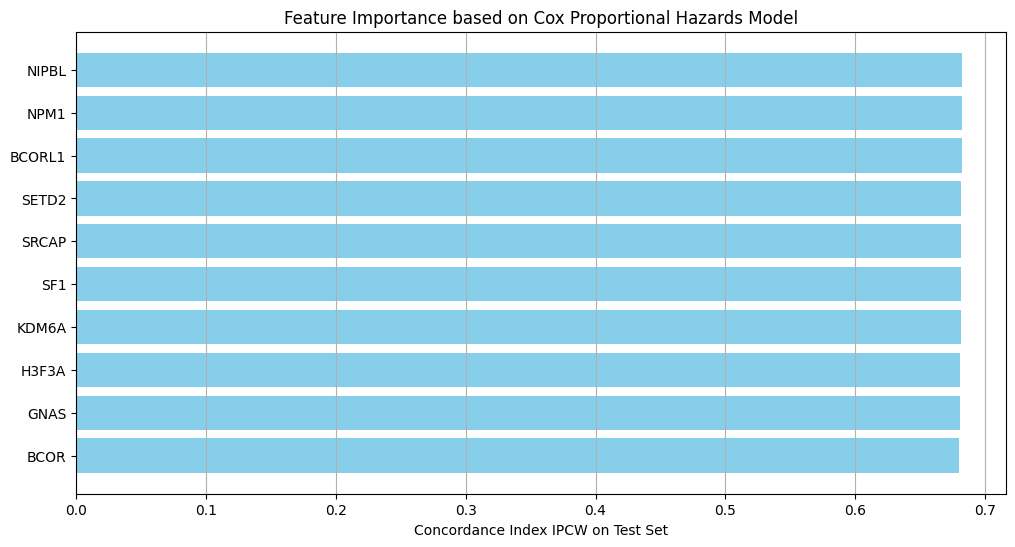

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [365]:
cox_cindex_test_list = []
cox_cindex_train_list = []
for effect in list_genes:
    features = ['BM_BLAST', 'HB', 'PLT','Mutation_Count',effect]
    # Create the survival data format
    X = df_factors.loc[df['ID'].isin(target_df['ID']), features]
    y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Survival-aware imputation for missing values
    imputer = SimpleImputer(strategy="median")
    X_train[features] = imputer.fit_transform(X_train[features])
    X_test[features] = imputer.transform(X_test[features])

    # Initialize and train the Cox Proportional Hazards model
    cox = CoxPHSurvivalAnalysis()
    try:
        cox.fit(X_train, y_train)
    except Exception as e:
        continue
    # Evaluate the model using Concordance Index IPCW
    cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
    cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
    cox_cindex_test_list.append((effect,cox_cindex_test))
    cox_cindex_train_list.append((effect,cox_cindex_train))

plt.figure(figsize=(12, 6))
cox_cindex_test_list.sort(key=lambda x: x[1])
features_sorted, cindex_values = zip(*cox_cindex_test_list)
plt.barh(features_sorted[:10], cindex_values[:10], color='skyblue')
plt.xlabel('Concordance Index IPCW on Test Set')
plt.title('Feature Importance based on Cox Proportional Hazards Model')
plt.grid(axis='x')
plt.show()
plt.figure(figsize=(12, 6))


##### Heat map test

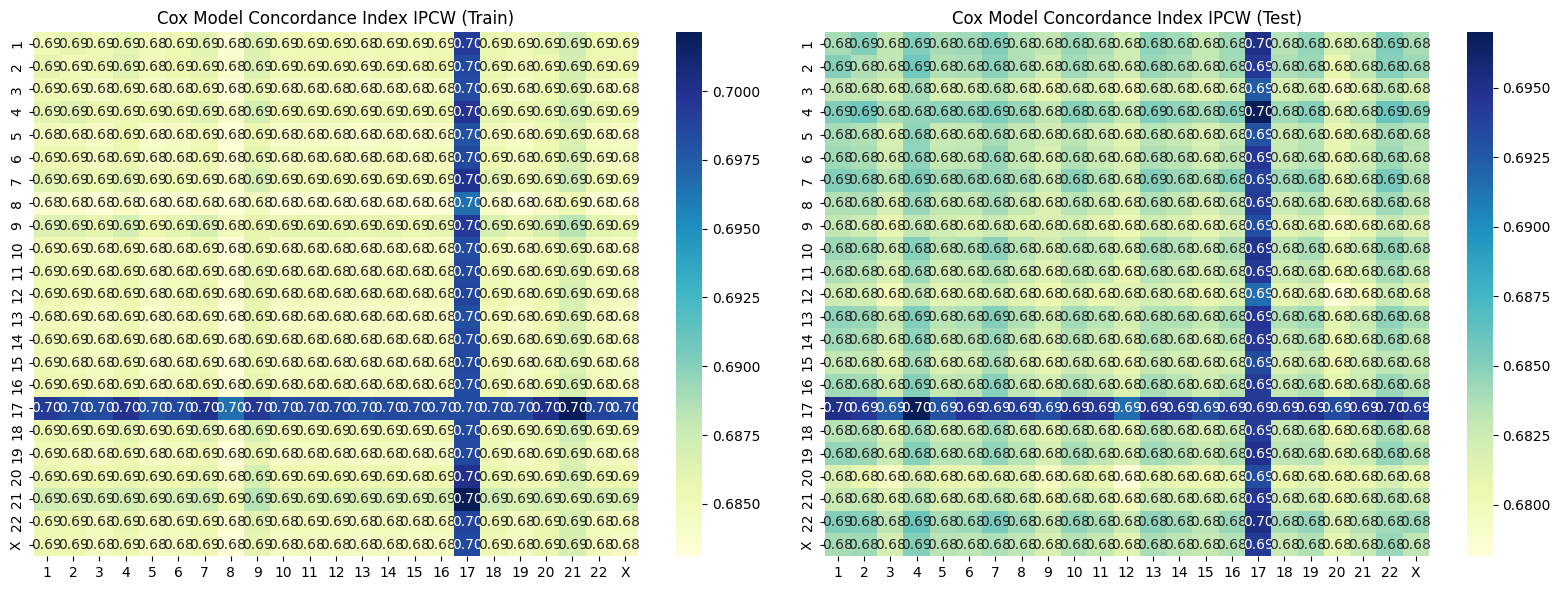

In [215]:
cox_index_list = []
for i, c1 in enumerate(Chromosomes):
    cox_index_list_inner = []
    for j, c2 in enumerate(Chromosomes):
        if i == j:
            features = ['BM_BLAST', 'HB', 'PLT', 'Mutation_Count', c1]
            X = df_factors.loc[df['ID'].isin(target_df['ID']), features]
            y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

            # Split the data into training and testing sets
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

            # Survival-aware imputation for missing values
            imputer = SimpleImputer(strategy="median")
            X_train[features] = imputer.fit_transform(X_train[features])
            X_test[features] = imputer.transform(X_test[features])

            # Initialize and train the Cox Proportional Hazards model
            cox = CoxPHSurvivalAnalysis()
            cox.fit(X_train, y_train)
            # Evaluate the model using Concordance Index IPCW
            cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
            cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
            cox_index_list_inner.append((c1,c2,cox_cindex_train,cox_cindex_test))
            continue
        features = ['BM_BLAST', 'HB', 'PLT','Mutation_Count', c1, c2]
        target = ['OS_YEARS', 'OS_STATUS']

        # Create the survival data format
        X = df_factors.loc[df['ID'].isin(target_df['ID']), features]
        y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

        # Split the data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

        # Survival-aware imputation for missing values
        imputer = SimpleImputer(strategy="median")
        X_train[features] = imputer.fit_transform(X_train[features])
        X_test[features] = imputer.transform(X_test[features])

        # Initialize and train the Cox Proportional Hazards model
        cox = CoxPHSurvivalAnalysis()
        cox.fit(X_train, y_train)
        # Evaluate the model using Concordance Index IPCW
        cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
        cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
        cox_index_list_inner.append((c1,c2,cox_cindex_train,cox_cindex_test))
    cox_index_list.append(cox_index_list_inner)

# Plotting heatmaps
import seaborn as sns
cox_index_array_train = np.array([[item[2] for item in sublist] for sublist in cox_index_list])
cox_index_array_test = np.array([[item[3] for item in sublist] for sublist in cox_index_list])
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.heatmap(cox_index_array_train, xticklabels=Chromosomes, yticklabels=Chromosomes, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Cox Model Concordance Index IPCW (Train)")
plt.subplot(1, 2, 2)
sns.heatmap(cox_index_array_test, xticklabels=Chromosomes, yticklabels=Chromosomes, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Cox Model Concordance Index IPCW (Test)")
plt.tight_layout()
plt.show()

#### Remarks:
- The heat map gives chromosomes 4 and 17 as the best pair (0.700 train 0.697 test ) for the sum of VAF on each chromosome
- Adding chromosome 21 gives 0.707 train 0.698 test

#### Submission of this result

In [ ]:
df_eval = pd.read_csv("./data/X_test/clinical_test.csv")
maf_eval = pd.read_csv("./data/X_test/molecular_test.csv")

tmp_eval = df_eval.copy()
tmp_eval = pd.concat([tmp_eval, start_end_depth_biggest_VAF(tmp_eval, maf_eval)], axis=1)
tmp_eval = pd.concat([tmp_eval, count_Vaf_CHRs(tmp_eval, maf_eval)], axis=1)
tmp_eval['Cytogenetic_Abnormality_Count'] = quantify_cytogenetic_abnormalities(df_eval)
tmp_eval['Mutation_Count'] = count_mutations(tmp_eval, maf_eval)

tmp_eval.head(10)

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,START,...,17,18,19,20,21,22,X,Y,Cytogenetic_Abnormality_Count,Mutation_Count
0,KYW1,KYW,68.0,3.45,0.5865,NaN,7.6,48.0,"47,XY,+X,del(9)(q?)[15]/47,XY,+X[5]",25467449,...,0.000,0.000,0.000,0.000,0.000,0.0,0.027,0.0,20,4.0
1,KYW2,KYW,35.0,3.18,1.2402,NaN,10.0,32.0,"46,XY,der(3)?t(3;11)(q26.2;q23),add(4)(p15).de...",39931853,...,0.000,0.000,0.000,0.000,0.000,0.0,0.713,0.0,20,3.0
2,KYW3,KYW,NaN,12.40,8.6800,NaN,12.3,25.0,"47,XX,+8",106158370,...,0.000,0.000,0.000,0.161,0.000,0.0,0.000,0.0,0,3.0
3,KYW4,KYW,61.0,5.55,2.0535,NaN,8.0,44.0,Normal,36253001,...,0.000,0.000,0.000,0.000,0.428,0.0,0.000,0.0,0,3.0
4,KYW5,KYW,2.0,1.21,0.7381,NaN,8.6,27.0,"43,XY,dic(5;17)(q11.2;p11.2),-7,-13,-20,-22,+r...",58740809,...,0.407,0.000,0.000,0.035,0.349,0.0,0.000,0.0,16,3.0
5,KYW6,KYW,27.0,1.35,0.3915,NaN,4.1,148.0,Normal,25457242,...,0.197,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0,3.0
6,KYW7,KYW,2.0,6.90,5.2095,NaN,7.5,94.0,"46,XY,del(11)(q?)",101923374,...,0.390,0.000,0.000,0.000,0.364,0.0,0.000,0.0,0,3.0
7,KYW8,KYW,9.0,5.73,3.8391,NaN,7.8,195.0,"46,XY,del(5)(q13q15)[20]",36252877,...,0.000,0.436,0.298,0.000,0.465,0.0,0.000,0.0,20,5.0
8,KYW9,KYW,2.0,NaN,NaN,NaN,NaN,NaN,Normal,25464439,...,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0,1.0
9,KYW10,KYW,1.0,1.61,0.6118,NaN,9.9,85.0,"47,XY,+8",15818039,...,0.000,0.000,0.000,0.258,0.000,0.0,0.475,0.0,0,2.0


In [260]:
tmp_eval[features] = imputer.transform(tmp_eval[features])
prediction_on_test_set = cox.predict(tmp_eval.loc[:, features])
prediction_on_test_set

submission = pd.Series(prediction_on_test_set, index=df_eval['ID'], name='risk_score')
submission.to_csv('./submission/cox_anomalycount_mutationcount.csv')


### Step 7: Volontarly overfitting

In [281]:
# Select features
Chromosomes = [str(i) for i in range(1, 23)] + ['X']
features = ['BM_BLAST', 'ANC', 'WBC','HB', 'PLT','Cytogenetic_Abnormality_Count','Mutation_Count','Complex_Ref_Mutation'] + Chromosomes
target = ['OS_YEARS', 'OS_STATUS']

# Create the survival data format
X = df_factors.loc[df['ID'].isin(target_df['ID']), features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Survival-aware imputation for missing values
imputer = SimpleImputer(strategy="median")
X_train[features] = imputer.fit_transform(X_train[features])
X_test[features] = imputer.transform(X_test[features])

# Initialize and train the Cox Proportional Hazards model
cox = CoxPHSurvivalAnalysis()
cox.fit(X_train, y_train)
# Evaluate the model using Concordance Index IPCW
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {cox_cindex_train:.3f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {cox_cindex_test:.3f}")

Cox Proportional Hazard Model Concordance Index IPCW on train: 0.710
Cox Proportional Hazard Model Concordance Index IPCW on test: 0.694


#### Submiting

In [282]:
features = ['BM_BLAST', 'ANC', 'WBC','HB', 'PLT','Cytogenetic_Abnormality_Count','Mutation_Count','Complex_Ref_Mutation'] + Chromosomes

df_eval = pd.read_csv("./data/X_test/clinical_test.csv")
maf_eval = pd.read_csv("./data/X_test/molecular_test.csv")

tmp_eval = df_eval.copy()
tmp_eval = pd.concat([tmp_eval, start_end_depth_biggest_VAF(tmp_eval, maf_eval)], axis=1)
tmp_eval = pd.concat([tmp_eval, count_Vaf_CHRs(tmp_eval, maf_eval)], axis=1)
tmp_eval['Cytogenetic_Abnormality_Count'] = quantify_cytogenetic_abnormalities(df_eval)
tmp_eval['Mutation_Count'] = count_mutations(tmp_eval, maf_eval)
tmp_eval['Complex_Ref_Mutation'] = lenght_reference(tmp_eval, maf_eval)
tmp_eval.head(10)

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,START,...,18,19,20,21,22,X,Y,Cytogenetic_Abnormality_Count,Mutation_Count,Complex_Ref_Mutation
0,KYW1,KYW,68.0,3.45,0.5865,NaN,7.6,48.0,"47,XY,+X,del(9)(q?)[15]/47,XY,+X[5]",25467449,...,0.000,0.000,0.000,0.000,0.0,0.027,0.0,20,4.0,1.0
1,KYW2,KYW,35.0,3.18,1.2402,NaN,10.0,32.0,"46,XY,der(3)?t(3;11)(q26.2;q23),add(4)(p15).de...",39931853,...,0.000,0.000,0.000,0.000,0.0,0.713,0.0,20,3.0,1.0
2,KYW3,KYW,NaN,12.40,8.6800,NaN,12.3,25.0,"47,XX,+8",106158370,...,0.000,0.000,0.161,0.000,0.0,0.000,0.0,0,3.0,2.0
3,KYW4,KYW,61.0,5.55,2.0535,NaN,8.0,44.0,Normal,36253001,...,0.000,0.000,0.000,0.428,0.0,0.000,0.0,0,3.0,1.0
4,KYW5,KYW,2.0,1.21,0.7381,NaN,8.6,27.0,"43,XY,dic(5;17)(q11.2;p11.2),-7,-13,-20,-22,+r...",58740809,...,0.000,0.000,0.035,0.349,0.0,0.000,0.0,16,3.0,1.0
5,KYW6,KYW,27.0,1.35,0.3915,NaN,4.1,148.0,Normal,25457242,...,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0,3.0,24.0
6,KYW7,KYW,2.0,6.90,5.2095,NaN,7.5,94.0,"46,XY,del(11)(q?)",101923374,...,0.000,0.000,0.000,0.364,0.0,0.000,0.0,0,3.0,1.0
7,KYW8,KYW,9.0,5.73,3.8391,NaN,7.8,195.0,"46,XY,del(5)(q13q15)[20]",36252877,...,0.436,0.298,0.000,0.465,0.0,0.000,0.0,20,5.0,15.0
8,KYW9,KYW,2.0,NaN,NaN,NaN,NaN,NaN,Normal,25464439,...,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0,1.0,1.0
9,KYW10,KYW,1.0,1.61,0.6118,NaN,9.9,85.0,"47,XY,+8",15818039,...,0.000,0.000,0.258,0.000,0.0,0.475,0.0,0,2.0,1.0


In [283]:
tmp_eval[features] = imputer.transform(tmp_eval[features])
prediction_on_test_set = cox.predict(tmp_eval.loc[:, features])
prediction_on_test_set

submission = pd.Series(prediction_on_test_set, index=df_eval['ID'], name='risk_score')
submission.to_csv('./submission/cox_anomalycount_mutationcount.csv')
